# Segmentation clients — Credit Score Classification

Ce notebook segmente les 12 500 clients de `data/train_features.csv` en
groupes homogènes à l'aide de **K-Means**, un algorithme non supervisé :
contrairement aux notebooks précédents, l'objectif n'est pas de prédire
`Credit_Score` mais de **découvrir des profils clients** pour orienter des
actions commerciales ciblées.

**Plan :**
1. Chargement et sélection des variables
2. Standardisation
3. Choix du nombre de clusters K
4. K-Means final
5. Visualisation PCA 2D
6. Profiling des clusters
7. Nommage et description des segments
8. Export

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

# Palette de statut pour la cible (fixe, jamais recyclée pour autre chose)
STATUS_COLORS = {
    'Good': '#0ca30c',
    'Standard': '#fab219',
    'Poor': '#d03b3b',
}
CREDIT_SCORE_ORDER = ['Good', 'Standard', 'Poor']

SEQUENTIAL_BLUE = '#2a78d6'
PRIMARY_INK = '#0b0b0b'
SECONDARY_INK = '#52514e'
MUTED_INK = '#898781'
GRID_COLOR = '#e1e0d9'
SURFACE = '#fcfcfb'

# Palette divergente bleu (négatif) -> gris neutre (0) -> rouge (positif)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'diverging_blue_red', ['#2a78d6', '#f0efec', '#e34948']
)

# Palette catégorielle (ordre fixe) pour les 4 segments de clients
CLUSTER_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#4a3aa7']
SEQUENTIAL_CMAP = sns.light_palette(SEQUENTIAL_BLUE, as_cmap=True)

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID_COLOR,
    'axes.grid': True,
    'grid.color': GRID_COLOR,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': PRIMARY_INK,
    'axes.labelcolor': SECONDARY_INK,
    'xtick.color': MUTED_INK,
    'ytick.color': MUTED_INK,
    'text.color': PRIMARY_INK,
    'font.family': 'sans-serif',
    'font.size': 10.5,
})
sns.set_style('whitegrid', {'axes.facecolor': SURFACE, 'grid.color': GRID_COLOR})

## 1. Chargement et sélection des variables

La segmentation porte sur `data/train_features.csv` (une ligne par client,
12 500 clients). Contrairement à la modélisation supervisée, K-Means ne
regarde pas `Credit_Score` : il regroupe les clients uniquement à partir de
leurs caractéristiques, pour découvrir des profils homogènes exploitables
commercialement.

On retient **8 variables** qui couvrent des dimensions complémentaires du
profil client :

- **Profil démographique** : `Age`.
- **Richesse** : `Annual_Income`.
- **Élasticité des revenus** (le focus du projet) : `Volatilite_Residuelle`,
  l'écart-type des résidus d'une régression log-linéaire du solde mensuel —
  l'instabilité réelle du client une fois sa tendance retirée (élevé = flux
  irréguliers, typiquement un commerçant).
- **Endettement** : `Ratio_Dette_Revenu`, le poids de la dette par rapport au
  revenu annuel.
- **Engagement bancaire** : `Nb_produits`, le nombre de produits détenus
  (comptes, cartes, prêts).
- **Ancienneté** : `Credit_History_Age_Months`, l'ancienneté de la relation de
  crédit.
- **Épargne / investissement** : `Taux_Investissement`, la part du salaire
  investie chaque mois.
- **Comportement de paiement** : `Delay_from_due_date`, le retard moyen de
  paiement en jours.

Ces variables sont déjà propres (voir `03_feature_engineering.ipynb`), mais on
neutralise par sécurité d'éventuelles valeurs infinies (ratios) avant
d'imputer les valeurs manquantes par la médiane — un choix robuste aux valeurs
extrêmes, adapté à des variables aux distributions asymétriques comme
`Annual_Income` ou `Ratio_Dette_Revenu`.

### Décision data-driven : exclusion d'`Elasticite_Tendance` de la segmentation

`03_feature_engineering.ipynb` décompose l'élasticité des revenus en deux
dimensions : `Elasticite_Tendance` (la croissance/décroissance moyenne du
solde) et `Volatilite_Residuelle` (l'instabilité une fois la tendance
retirée). Nous avions testé les deux dimensions ensemble dans la
segmentation (9 variables). L'analyse du profil moyen par cluster a montré
que `Elasticite_Tendance` **ne différencie pas les clusters** : l'étendue de
ses moyennes entre les 4 clusters n'est que de **0.003**, alors que sa
dispersion **intra-cluster** (écart-type au sein de chaque cluster) est de
**0.02 à 0.09** — près de 10 à 30 fois plus grande. Autrement dit, aucun
segment ne présente de tendance systématique sur les 8 mois observés : les
écarts entre clusters sont noyés dans le bruit intra-cluster.

`Elasticite_Tendance` est donc **retirée de la segmentation**, où elle
n'ajouterait que du bruit aux distances euclidiennes de K-Means (une
variable standardisée sans signal, mais qui pèse quand même dans le calcul de
distance, diluant les dimensions réellement discriminantes). Elle est en
revanche **conservée dans `data/train_features.csv`** pour le modèle de
scoring : son pouvoir prédictif *individuel* vis-à-vis de `Credit_Score` (par
opposition à son pouvoir de séparation en clusters) reste à évaluer, et sera
mesuré par analyse SHAP lors de la modélisation. `Volatilite_Residuelle`
reste la mesure d'élasticité retenue pour la segmentation, à la place de
l'ancien `CV_Balance`.

In [2]:
df = pd.read_csv('../data/train_features.csv')
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")

VARIABLES_SEGMENTATION = [
    'Age', 'Annual_Income', 'Volatilite_Residuelle', 'Ratio_Dette_Revenu',
    'Nb_produits', 'Credit_History_Age_Months', 'Taux_Investissement',
    'Delay_from_due_date',
]

X = df[VARIABLES_SEGMENTATION].copy()

n_infinies = int(np.isinf(X.to_numpy(dtype=float)).sum())
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Valeurs infinies neutralisées : {n_infinies}")

n_manquantes = int(X.isna().sum().sum())
X = X.fillna(X.median())
print(f"Valeurs manquantes imputées par la médiane : {n_manquantes}")

X.describe().T

Dimensions : 12500 lignes x 56 colonnes
Valeurs infinies neutralisées : 0
Valeurs manquantes imputées par la médiane : 0


,count,mean,std,min,25%,50%,75%,max
Age,12500.0,34.337570,9.854151,18.000000,26.125000,34.000000,41.750000,56.500000
Annual_Income,12500.0,50518.846732,38300.174697,7005.930000,19358.250000,37037.320000,71689.865000,179987.280000
Volatilite_Residuelle,12500.0,0.287927,0.258322,0.010920,0.120083,0.208326,0.366670,3.904802
Ratio_Dette_Revenu,12500.0,0.060648,0.087395,0.000003,0.009572,0.028249,0.069716,0.683252
Nb_produits,12500.0,14.435630,5.651335,1.000000,10.000000,14.000000,19.000000,29.000000
Credit_History_Age_Months,12500.0,221.136220,99.658098,4.500000,144.500000,218.500000,301.500000,400.500000
Taux_Investissement,12500.0,0.052211,0.015452,0.013634,0.040723,0.050780,0.062648,0.116377
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000


## 2. Standardisation

K-Means regroupe les points en fonction de leur **distance euclidienne** au
centroïde de chaque cluster. Sans mise à l'échelle, les variables aux valeurs
les plus grandes dominent mécaniquement la distance : ici `Annual_Income`
varie sur une échelle de dizaines de milliers (~50 000 en moyenne) alors que
`Age` varie entre 14 et 56 ans (~33 en moyenne). Un écart de 10 000 sur le
revenu et un écart de 10 ans sur l'âge auraient un poids totalement
disproportionné dans le calcul de distance si on ne les ramenait pas à la même
échelle.

`StandardScaler` centre chaque variable sur une moyenne de 0 et une
écart-type de 1 : toutes les variables contribuent alors à parts comparables
à la distance entre clients.

In [3]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), columns=VARIABLES_SEGMENTATION, index=X.index,
)

print("Moyennes après standardisation (doivent être ~0) :")
print(X_scaled.mean().round(3))
print("\nÉcarts-types après standardisation (doivent être ~1) :")
print(X_scaled.std().round(3))

Moyennes après standardisation (doivent être ~0) :
Age                          0.0
Annual_Income               -0.0
Volatilite_Residuelle        0.0
Ratio_Dette_Revenu           0.0
Nb_produits                  0.0
Credit_History_Age_Months   -0.0
Taux_Investissement         -0.0
Delay_from_due_date         -0.0
dtype: float64

Écarts-types après standardisation (doivent être ~1) :
Age                          1.0
Annual_Income                1.0
Volatilite_Residuelle        1.0
Ratio_Dette_Revenu           1.0
Nb_produits                  1.0
Credit_History_Age_Months    1.0
Taux_Investissement          1.0
Delay_from_due_date          1.0
dtype: float64


## 3. Choix du nombre de clusters K

Deux critères guident le choix de K :

- **La méthode du coude (inertie)** : l'inertie mesure la somme des distances
  au carré entre chaque point et le centroïde de son cluster. Elle décroît
  mécaniquement avec K ; on cherche le point où les gains marginaux
  ralentissent nettement (le "coude").
- **Le score de silhouette** : mesure, pour chaque point, à quel point il est
  bien regroupé dans son cluster par rapport aux clusters voisins (entre -1 et
  1, plus haut = meilleure séparation). Calculé ici sur un échantillon de
  5 000 clients (`sample_size=5000`) pour rester rapide, avec une graine fixe
  pour la reproductibilité.

On teste K de 2 à 10, avec `n_init=10` pour limiter le risque de convergence
vers un minimum local.

In [4]:
resultats_k = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    resultats_k.append({'K': k, 'Inertie': km.inertia_, 'Silhouette': sil})

df_k = pd.DataFrame(resultats_k)
df_k.round(4)

,K,Inertie,Silhouette
0,2,72337.0337,0.2664
1,3,61556.9102,0.2016
2,4,53929.6041,0.2098
3,5,49456.3640,0.1822
4,6,45718.5352,0.1864
5,7,42822.6027,0.1787
6,8,40698.4403,0.1736
7,9,38690.8442,0.1699
8,10,37037.8883,0.1641


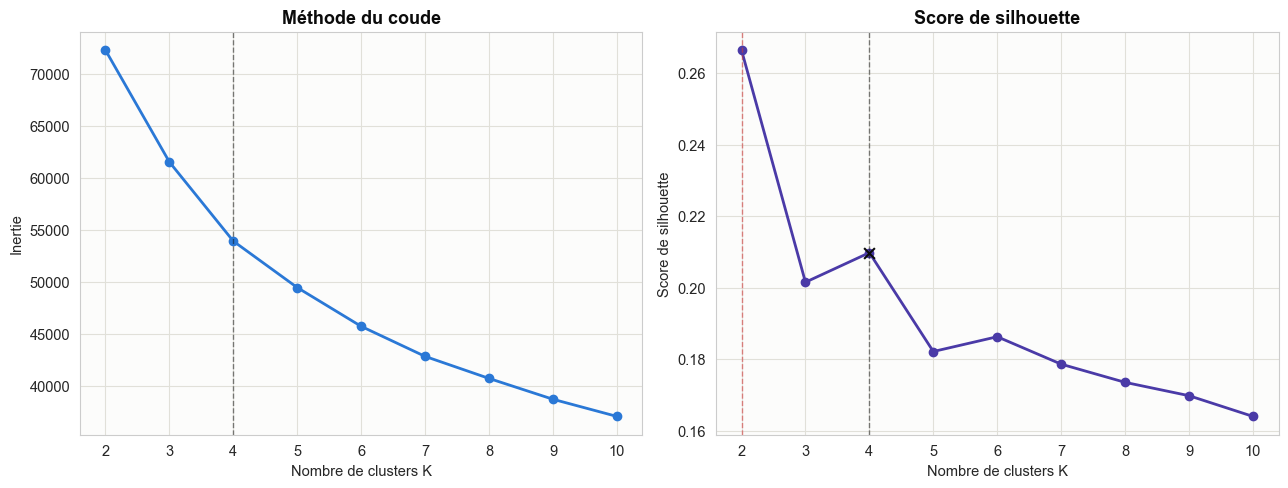

Silhouette à K=2 : 0.2664
Silhouette à K=4 : 0.2098


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(df_k['K'], df_k['Inertie'], marker='o', color=SEQUENTIAL_BLUE, linewidth=2)
ax.axvline(4, color=PRIMARY_INK, linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Nombre de clusters K')
ax.set_ylabel('Inertie')
ax.set_title("Méthode du coude")
ax.set_xticks(df_k['K'])

ax = axes[1]
ax.plot(df_k['K'], df_k['Silhouette'], marker='o', color='#4a3aa7', linewidth=2)
ax.axvline(2, color=STATUS_COLORS['Poor'], linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(4, color=PRIMARY_INK, linestyle='--', linewidth=1, alpha=0.5)
silhouette_k4 = df_k.loc[df_k['K'] == 4, 'Silhouette'].values[0]
ax.scatter([4], [silhouette_k4], color=PRIMARY_INK, zorder=5, s=60, marker='x')
ax.set_xlabel('Nombre de clusters K')
ax.set_ylabel('Score de silhouette')
ax.set_title("Score de silhouette")
ax.set_xticks(df_k['K'])

plt.tight_layout()
plt.show()

silhouette_k2 = df_k.loc[df_k['K'] == 2, 'Silhouette'].values[0]
print(f"Silhouette à K=2 : {silhouette_k2:.4f}")
print(f"Silhouette à K=4 : {silhouette_k4:.4f}")

### Décision : K = 4

Les deux courbes suivent la même logique qu'avec les versions précédentes :
le score de silhouette est **maximal à K=2 (~0.266)**, chute nettement à
K=3 (~0.202), puis remonte nettement à K=4 (~0.210) — un **rebond net**, qui
reste le **deuxième meilleur score de silhouette de toute la plage testée**
(K=2 excepté), supérieur à toutes les valeurs obtenues pour K=5 à K=10
(entre 0.16 et 0.19).

Retirer `Elasticite_Tendance` **améliore même légèrement** la silhouette à
K=4 (0.210, contre 0.189 avec les 9 variables) : sans signal réel entre
clusters, elle ajoutait du bruit à la distance euclidienne de K-Means — une
confirmation supplémentaire de la décision data-driven prise en section 1.

K=2 reste optimal au sens mathématique strict, mais **trop pauvre pour
l'exploitation business** : un partitionnement en 2 groupes ne permet pas de
distinguer des profils de clients aux besoins différents, et n'apporte aucune
granularité actionnable pour des campagnes ciblées.

On retient donc **K=4**, qui combine :
- un rebond de silhouette net et le meilleur score après K=2 (pas un choix
  arbitraire sur une courbe plate),
- une granularité alignée avec le cahier des charges métier, qui distingue
  typiquement des profils tels que salariés stables, clients premium à forte
  élasticité, jeunes clients en construction de crédit et clients endettés.

## 4. K-Means final (K=4)

On ajuste le modèle final avec K=4 sur l'ensemble des 12 500 clients, et on
reporte l'étiquette de cluster obtenue directement dans le dataframe original
(non standardisé) pour faciliter l'interprétation.

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

tailles = df['Cluster'].value_counts().sort_index()
pourcentages = (tailles / len(df) * 100).round(2)

resume_tailles = pd.DataFrame({'Effectif': tailles, 'Part (%)': pourcentages})
resume_tailles

,Effectif,Part (%)
Cluster,,
0,1961,15.69
1,3313,26.50
2,4735,37.88
3,2491,19.93


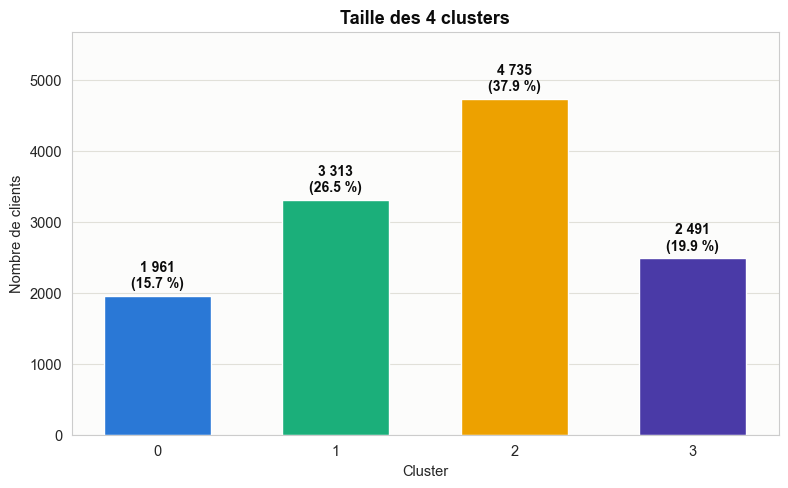

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    resume_tailles.index.astype(str), resume_tailles['Effectif'],
    color=CLUSTER_COLORS, width=0.6,
)
for bar, eff, pct in zip(bars, resume_tailles['Effectif'], resume_tailles['Part (%)']):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + tailles.max() * 0.015,
        f"{eff:,}".replace(',', ' ') + f"\n({pct:.1f} %)",
        ha='center', va='bottom', fontsize=10, color=PRIMARY_INK, fontweight='bold',
    )
ax.set_ylim(0, tailles.max() * 1.2)
ax.set_xlabel('Cluster')
ax.set_ylabel('Nombre de clients')
ax.set_title("Taille des 4 clusters")
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

## 5. Visualisation PCA 2D

Les 8 variables standardisées définissent un espace à 8 dimensions,
impossible à visualiser directement. L'**ACP (analyse en composantes
principales)** projette ces 8 dimensions sur les 2 axes qui capturent le plus
de variance, pour visualiser — de façon approximative mais utile — la
séparation entre clusters.

Variance expliquée : axe 1 = 39.6 %, axe 2 = 19.0 % (total = 58.6 %)


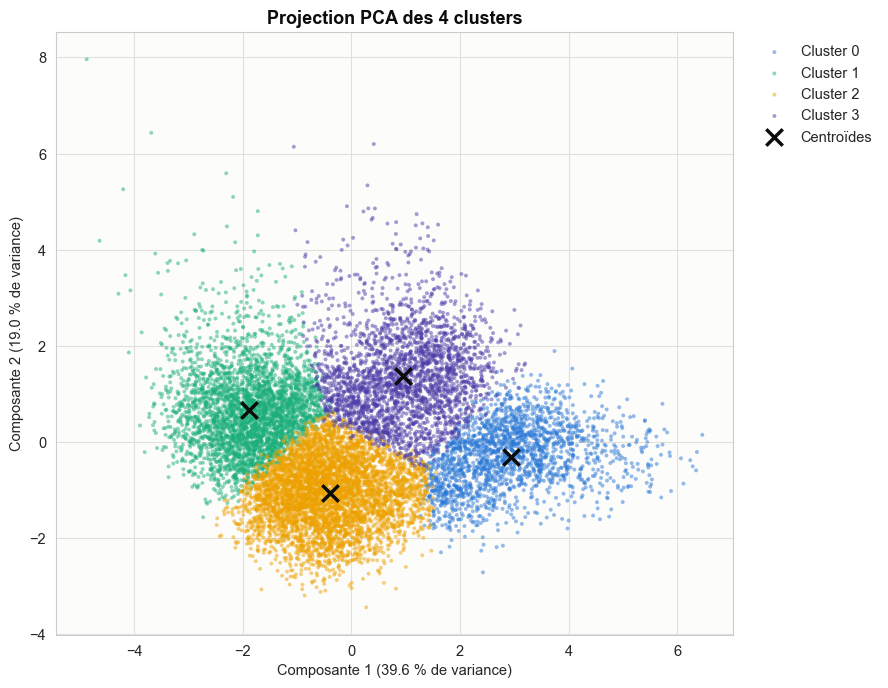

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroides_pca = pca.transform(pd.DataFrame(kmeans.cluster_centers_, columns=VARIABLES_SEGMENTATION))

variance_expliquee = pca.explained_variance_ratio_
print(f"Variance expliquée : axe 1 = {variance_expliquee[0]*100:.1f} %, "
      f"axe 2 = {variance_expliquee[1]*100:.1f} % "
      f"(total = {variance_expliquee.sum()*100:.1f} %)")

fig, ax = plt.subplots(figsize=(9, 7))
for cluster_id, couleur in enumerate(CLUSTER_COLORS):
    mask = (df['Cluster'] == cluster_id).values
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.5, color=couleur,
        label=f"Cluster {cluster_id}", edgecolor='none',
    )
ax.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1], marker='x', s=140,
    color=PRIMARY_INK, linewidth=2.5, label='Centroïdes', zorder=5,
)
ax.set_xlabel(f"Composante 1 ({variance_expliquee[0]*100:.1f} % de variance)")
ax.set_ylabel(f"Composante 2 ({variance_expliquee[1]*100:.1f} % de variance)")
ax.set_title("Projection PCA des 4 clusters")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

## 6. Profiling des clusters

On caractérise maintenant chaque cluster à partir des 8 variables de
segmentation, puis on croise les clusters avec `Credit_Score` (non utilisé
pour la segmentation, mais utile pour valider la pertinence business des
groupes trouvés).

### a) Moyennes des variables par cluster

In [9]:
profil_moyen = df.groupby('Cluster')[VARIABLES_SEGMENTATION].mean().round(2)
profil_moyen

,Age,Annual_Income,Volatilite_Residuelle,Ratio_Dette_Revenu,Nb_produits,Credit_History_Age_Months,Taux_Investissement,Delay_from_due_date
Cluster,,,,,,,,
0,31.66,14222.35,0.11,0.22,20.91,121.70,0.07,35.23
1,35.98,102037.02,0.46,0.01,10.72,282.58,0.04,13.15
2,35.96,29418.67,0.18,0.04,11.42,269.04,0.06,14.06
3,31.17,50682.25,0.40,0.05,20.01,126.64,0.05,33.76


### b) Heatmap normalisée

Les 8 variables ont des échelles très différentes (l'âge varie entre 0 et
100, le revenu entre 0 et 100 000+) : une heatmap directe des moyennes serait
dominée visuellement par les variables aux plus grandes valeurs. On normalise
donc chaque variable (colonne) entre 0 et 1 par min-max **sur les moyennes des
4 clusters** (pas sur les données brutes), pour lire d'un coup d'œil quel
cluster est "haut" ou "bas" sur chaque dimension. Les valeurs annotées restent
les vraies moyennes, seule la couleur encode la position relative.

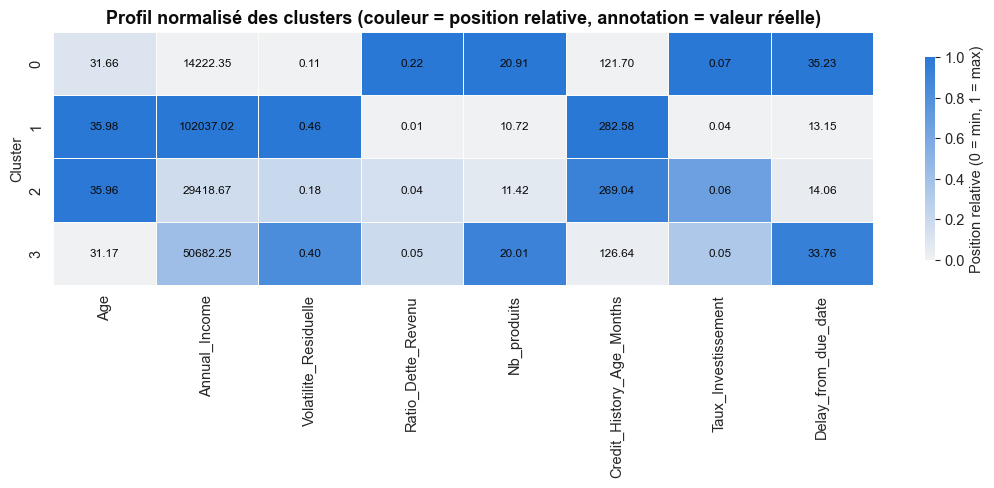

In [10]:
profil_normalise = (profil_moyen - profil_moyen.min()) / (profil_moyen.max() - profil_moyen.min())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    profil_normalise, cmap=SEQUENTIAL_CMAP, vmin=0, vmax=1,
    annot=profil_moyen, fmt='.2f', annot_kws={'size': 8.5, 'color': PRIMARY_INK},
    linewidths=0.6, linecolor=SURFACE,
    cbar_kws={'label': 'Position relative (0 = min, 1 = max)', 'shrink': 0.8}, ax=ax,
)
ax.set_title("Profil normalisé des clusters (couleur = position relative, annotation = valeur réelle)")
ax.set_ylabel('Cluster')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### c) Distribution du `Credit_Score` par cluster

`Credit_Score` n'a pas été utilisé pour construire les clusters : le comparer
a posteriori permet de vérifier si les segments obtenus se distinguent aussi
par leur niveau de risque.

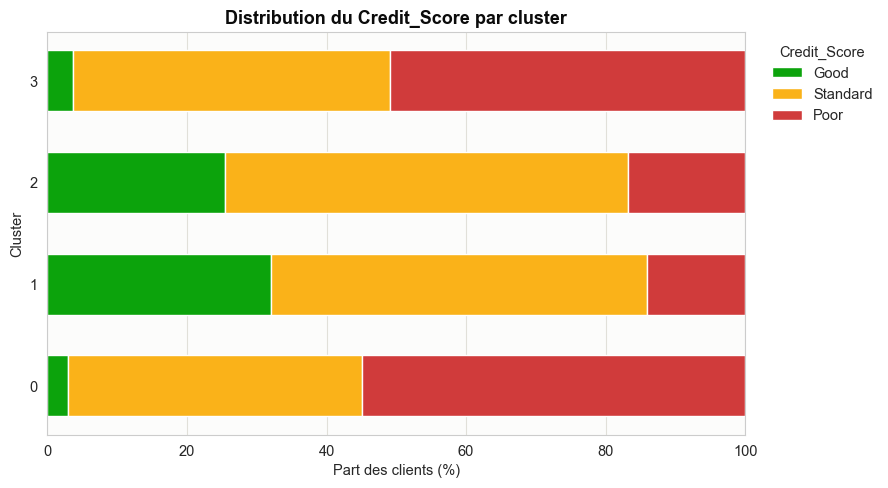

Credit_Score,Good,Standard,Poor
Cluster,,,
0,2.9,42.2,54.9
1,32.1,53.9,14.0
2,25.4,57.8,16.7
3,3.6,45.5,50.9


In [11]:
credit_score_par_cluster = (
    pd.crosstab(df['Cluster'], df['Credit_Score'], normalize='index')[CREDIT_SCORE_ORDER] * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
left = np.zeros(len(credit_score_par_cluster))
for classe in CREDIT_SCORE_ORDER:
    ax.barh(
        credit_score_par_cluster.index.astype(str), credit_score_par_cluster[classe],
        left=left, color=STATUS_COLORS[classe], label=classe, height=0.6,
    )
    left += credit_score_par_cluster[classe].values

ax.set_xlim(0, 100)
ax.set_xlabel('Part des clients (%)')
ax.set_ylabel('Cluster')
ax.set_title("Distribution du Credit_Score par cluster")
ax.grid(axis='y', visible=False)
ax.legend(title='Credit_Score', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

credit_score_par_cluster.round(1)

### d) `Volatilite_Residuelle` par cluster — l'élasticité des revenus

`Volatilite_Residuelle` est la variable au cœur du projet : elle distingue
les clients à revenus stables (salariés) des clients à revenus irréguliers
(commerçants, indépendants), une fois la tendance retirée par régression
log-linéaire (voir `03_feature_engineering.ipynb` et la décision data-driven
de la section 1). Le boxplot montre si cette élasticité varie fortement selon
les clusters, et confirme si K-Means a bien capté cette dimension dans le
regroupement.

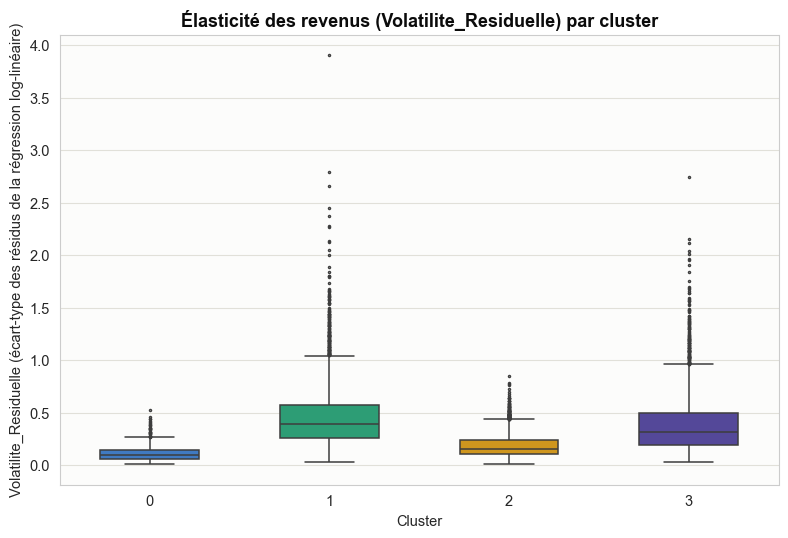

In [12]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(
    data=df, x='Cluster', y='Volatilite_Residuelle', hue='Cluster', palette=CLUSTER_COLORS,
    legend=False, width=0.55, fliersize=1.5, linewidth=1.1, ax=ax,
)
ax.set_xlabel('Cluster')
ax.set_ylabel('Volatilite_Residuelle (écart-type des résidus de la régression log-linéaire)')
ax.set_title("Élasticité des revenus (Volatilite_Residuelle) par cluster")
plt.tight_layout()
plt.show()

## 7. Nommage et description des segments

**Nommage dynamique** : l'ordre des index de cluster attribué par K-Means est
arbitraire (il peut changer d'une exécution à l'autre, y compris entre deux
runs avec des données quasi identiques). Les segments sont donc identifiés
par leurs **caractéristiques dominantes** plutôt que par leur index brut, afin
que les noms restent corrects même si K-Means réordonne les clusters :

1. Le cluster avec le `Ratio_Dette_Revenu` le plus élevé (nettement au-dessus
   des autres) → *Clients endettés à risque*.
2. Parmi les 3 restants, celui avec la `Volatilite_Residuelle` la plus
   élevée → *Clients aisés à forte élasticité (premium)*.
3. Parmi les 2 restants, celui avec l'historique de crédit
   (`Credit_History_Age_Months`) le plus long → *Salariés stables / clients
   matures*.
4. Le dernier restant → *Jeunes clients en construction de crédit*.

En croisant le profil moyen (section 6a-b) et la distribution du
`Credit_Score` (section 6c), quatre profils cohérents se dégagent :

### Clients endettés à risque

- **Profil** : les plus jeunes en moyenne (31.7 ans) avec le revenu annuel le
  plus faible (~14 200), un **`Ratio_Dette_Revenu` extrême** (0.22, soit 4 à
  20 fois plus élevé que les 3 autres clusters), un historique de crédit
  court (~122 mois), le plus grand retard moyen de paiement (35 jours) et la
  `Volatilite_Residuelle` la plus faible du dataset (0.11) : ce n'est pas un
  profil à revenus irréguliers, c'est bien l'endettement qui domine.
- **Risque** : 55 % de `Poor`, 42 % de `Standard`, seulement 3 % de `Good` —
  le cluster le plus risqué, de très loin.
- **Action business suggérée** : plafonner ou refuser les nouvelles lignes de
  crédit, proposer un accompagnement au désendettement (rééchelonnement,
  conseil budgétaire) plutôt que des produits supplémentaires.

### Clients aisés à forte élasticité (premium)

- **Profil** : le revenu annuel le plus élevé (~102 000) et la
  **`Volatilite_Residuelle` la plus élevée** (0.46) — le signal d'instabilité
  résiduelle le plus marqué, cohérent avec une activité indépendante ou
  commerciale aux flux de trésorerie irréguliers. Malgré cette instabilité,
  l'endettement est quasi nul (0.01) et le retard de paiement est le plus
  faible du dataset (13 jours), avec l'historique de crédit le plus long
  (~283 mois).
- **Risque** : le meilleur profil de risque du dataset — 32 % de `Good`,
  54 % de `Standard`, seulement 14 % de `Poor`.
- **Action business suggérée** : produits adaptés aux flux de trésorerie
  irréguliers (lignes de crédit flexibles, lissage saisonnier), offres
  patrimoniales/investissement haut de gamme — des clients aisés à fort
  potentiel malgré (ou grâce à) leur profil de revenus atypique.

### Salariés stables / clients matures

- **Profil** : le cluster le plus grand (37.9 % des clients). Clients plus
  âgés (36.0 ans), avec le **2ᵉ plus long historique de crédit** (~269 mois,
  ~22.4 ans), un endettement faible (`Ratio_Dette_Revenu` = 0.04), peu de
  retards (14 jours) et une `Volatilite_Residuelle` basse (0.18) — cohérent
  avec un revenu salarial régulier. Le revenu et le nombre de produits
  détenus restent modérés.
- **Risque** : le meilleur mix de `Credit_Score` en volume, avec `Standard`
  majoritaire (58 %), 25 % de `Good` et seulement 17 % de `Poor`.
- **Action business suggérée** : cœur de portefeuille à fidéliser —
  cross-sell de produits d'épargne/investissement, offres de fidélité,
  faible priorité de surveillance du risque.

### Jeunes clients en construction de crédit

- **Profil** : les clients les plus jeunes (31.2 ans) avec l'historique de
  crédit le plus court (~127 mois), mais un revenu correct (~50 700, le
  2ᵉ plus élevé) et un fort engagement bancaire (20.0 produits en moyenne,
  proche du maximum). Le retard de paiement reste élevé (34 jours) et la
  `Volatilite_Residuelle` est la 2ᵉ plus élevée (0.40) — un flux de solde
  assez instable.
- **Risque** : 51 % de `Poor`, 46 % de `Standard`, seulement 4 % de `Good` —
  un risque élevé, mais porté par le manque d'historique plus que par un
  surendettement (`Ratio_Dette_Revenu` = 0.05, dans la norme).
- **Action business suggérée** : construire l'historique de crédit (petites
  lignes de crédit renouvelable, cartes jeunes), canaux 100 % digitaux
  (appli mobile, onboarding rapide), programme d'éducation financière pour
  réduire les retards.

Les noms ci-dessus reflètent les moyennes réellement observées, ils ne sont
pas plaqués a priori. Les segments "Clients endettés à risque" et "Jeunes
clients en construction de crédit" partagent un âge et une ancienneté
proches, mais se distinguent nettement par le revenu et surtout par le
`Ratio_Dette_Revenu` (0.22 contre 0.05), ce qui justifie deux profils métier
différents plutôt qu'un seul groupe "jeunes clients".

In [13]:
def identifier_segments(profil):
    """Identifie les 4 profils métier à partir de leurs caractéristiques
    dominantes plutôt que de l'index de cluster (arbitraire selon
    l'exécution de K-Means, cf. section 7)."""
    restants = list(profil.index)
    noms = {}
    caracteristiques = {}

    c_endettes = profil.loc[restants, 'Ratio_Dette_Revenu'].idxmax()
    noms[c_endettes] = 'Clients endettés à risque'
    caracteristiques[c_endettes] = (
        f"Ratio_Dette_Revenu extrême ({profil.loc[c_endettes, 'Ratio_Dette_Revenu']:.2f})"
    )
    restants.remove(c_endettes)

    c_instables = profil.loc[restants, 'Volatilite_Residuelle'].idxmax()
    noms[c_instables] = 'Clients aisés à forte élasticité (premium)'
    caracteristiques[c_instables] = (
        f"Volatilite_Residuelle la plus élevée ({profil.loc[c_instables, 'Volatilite_Residuelle']:.2f})"
    )
    restants.remove(c_instables)

    c_salaries = profil.loc[restants, 'Credit_History_Age_Months'].idxmax()
    noms[c_salaries] = 'Salariés stables / clients matures'
    caracteristiques[c_salaries] = (
        f"Historique de crédit le plus long (~{profil.loc[c_salaries, 'Credit_History_Age_Months']:.0f} mois)"
    )
    restants.remove(c_salaries)

    c_jeunes = restants[0]
    noms[c_jeunes] = 'Jeunes clients en construction de crédit'
    caracteristiques[c_jeunes] = (
        f"Historique de crédit le plus court (~{profil.loc[c_jeunes, 'Credit_History_Age_Months']:.0f} mois)"
    )

    return noms, caracteristiques


NOMS_SEGMENTS, CARACTERISTIQUE_DOMINANTE = identifier_segments(profil_moyen)
df['Segment'] = df['Cluster'].map(NOMS_SEGMENTS)
df[['Cluster', 'Segment']].drop_duplicates().sort_values('Cluster').reset_index(drop=True)

,Cluster,Segment
0,0,Clients endettés à risque
1,1,Clients aisés à forte élasticité (premium)
2,2,Salariés stables / clients matures
3,3,Jeunes clients en construction de crédit


## 8. Export

On exporte la table complète (les colonnes de `train_features.csv` +
`Cluster` + `Segment`) vers `data/train_segments.csv`, et on résume chaque
segment par son effectif, sa part, sa caractéristique dominante et sa part de
`Poor`.

In [14]:
df.to_csv('../data/train_segments.csv', index=False)
print("Fichier exporté avec succès : data/train_segments.csv")
print(f"Dimensions exportées : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Fichier exporté avec succès : data/train_segments.csv
Dimensions exportées : 12500 lignes x 58 colonnes


In [15]:
part_poor = df.groupby('Cluster')['Credit_Score'].apply(lambda s: (s == 'Poor').mean() * 100).round(1)

resume_final = resume_tailles.copy()
resume_final['Segment'] = resume_final.index.map(NOMS_SEGMENTS)
resume_final['Caractéristique dominante'] = resume_final.index.map(CARACTERISTIQUE_DOMINANTE)
resume_final['Part de Poor (%)'] = part_poor
resume_final = resume_final[['Segment', 'Effectif', 'Part (%)', 'Caractéristique dominante', 'Part de Poor (%)']]
resume_final

,Segment,Effectif,Part (%),Caractéristique dominante,Part de Poor (%)
Cluster,,,,,
0,Clients endettés à risque,1961,15.69,Ratio_Dette_Revenu extrême (0.22),54.9
1,Clients aisés à forte élasticité (premium),3313,26.50,Volatilite_Residuelle la plus élevée (0.46),14.0
2,Salariés stables / clients matures,4735,37.88,Historique de crédit le plus long (~269 mois),16.7
3,Jeunes clients en construction de crédit,2491,19.93,Historique de crédit le plus court (~127 mois),50.9
